<a href="https://colab.research.google.com/github/Anya-ova/pytorch_classifier/blob/raw_neuro_project/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22neuro_project_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os
import time
import copy
import random
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from torchvision.transforms.functional import to_pil_image

In [3]:
plt.rcParams['figure.figsize'] = [12, 8]
plt.rcParams['figure.dpi'] = 100
sns.set_style("whitegrid")

In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [5]:
data_paths = {
      'base': '/content/drive/MyDrive/Colab Notebooks/neuro_project/data',
      'drilling_rig': '/content/drive/MyDrive/Colab Notebooks/neuro_project/data/drilling_rig',
      'pumping_unit': '/content/drive/MyDrive/Colab Notebooks/neuro_project/data/pumping_unit'
    }


In [6]:
class SimpleFolderDataset(Dataset):
    def __init__(self, data_paths, transform=None):
        self.transform = transform
        self.samples = []
        self.classes = ['drilling_rig', 'pumping_unit']
        self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}
        self.idx_to_class = {idx: cls for cls, idx in self.class_to_idx.items()}

        for class_name in self.classes:
            class_path = data_paths[class_name]
            if os.path.exists(class_path):
                for img_name in os.listdir(class_path):
                    if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                        img_path = os.path.join(class_path, img_name)
                        self.samples.append((img_path, self.class_to_idx[class_name]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        try:
            img = Image.open(img_path).convert('RGB')
            if self.transform:
                img = self.transform(img)
            return img, label, img_path
        except Exception as e:
            print(f"Ошибка загрузки {img_path}: {e}")
            dummy_img = Image.new('RGB', (224, 224), color='black')
            if self.transform:
                dummy_img = self.transform(dummy_img)
            return dummy_img, label, img_path

In [7]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Создание датасета
dataset = SimpleFolderDataset(data_paths, transform=transform)
print(f"Всего изображений: {len(dataset)}")
print(f"Классы: {dataset.classes}")

Всего изображений: 50
Классы: ['drilling_rig', 'pumping_unit']


In [8]:
models_dict = {
    'AlexNet': {
        'model': models.alexnet(weights=models.AlexNet_Weights.DEFAULT),
        'weights': models.AlexNet_Weights.DEFAULT,
        'preprocess': models.AlexNet_Weights.DEFAULT.transforms(),
        'output_layer': 'classifier',
        'in_features': lambda model: model.classifier[1].in_features,
        'feature_layer': 'classifier'
    },
    'DenseNet': {
        'model': models.densenet121(weights=models.DenseNet121_Weights.DEFAULT),
        'weights': models.DenseNet121_Weights.DEFAULT,
        'preprocess': models.DenseNet121_Weights.DEFAULT.transforms(),
        'output_layer': 'classifier',
        'in_features': lambda model: model.classifier.in_features,
        'feature_layer': 'features'
    },
    'MobileNet': {
        'model': models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT),
        'weights': models.MobileNet_V3_Small_Weights.DEFAULT,
        'preprocess': models.MobileNet_V3_Small_Weights.DEFAULT.transforms(),
        'output_layer': 'classifier',
        'in_features': lambda model: model.classifier[0].in_features,
        'feature_layer': 'features'
    },
    'ResNet50': {
        'model': models.resnet50(weights=models.ResNet50_Weights.DEFAULT),
        'weights': models.ResNet50_Weights.DEFAULT,
        'preprocess': models.ResNet50_Weights.DEFAULT.transforms(),
        'output_layer': 'fc',
        'in_features': lambda model: model.fc.in_features,
        'feature_layer': 'fc'
    },
    'SwinT': {
        'model': models.swin_t(weights=models.Swin_T_Weights.DEFAULT),
        'weights': models.Swin_T_Weights.DEFAULT,
        'preprocess': models.Swin_T_Weights.DEFAULT.transforms(),
        'output_layer': 'head',
        'in_features': lambda model: model.head.in_features,
        'feature_layer': 'head'
    }
}

In [9]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"\nУстройство: {device}")

for model_name, model_info in models_dict.items():
    model_info['model'] = model_info['model'].to(device)
    model_info['model'].eval()



Устройство: cpu


In [10]:
def denormalize(tensor):
    """Денормализация для отображения"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(-1, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(-1, 1, 1)
    tensor = tensor * std + mean
    return torch.clamp(tensor, 0, 1)

In [11]:
print("\n" + "="*80)
print("ТЕСТИРОВАНИЕ СКОРОСТИ КЛАССИФИКАЦИИ")
print("="*80)

def test_model_speed(model_info, dataloader, device_type='cpu'):
    """Тестирование скорости модели"""
    if device_type == 'cuda' and not torch.cuda.is_available():
        device_type = 'cpu'

    device = torch.device(device_type)
    model = copy.deepcopy(model_info['model'])
    model = model.to(device)
    model.eval()

    inference_times = []

    with torch.no_grad():
        for images, _, _ in dataloader:
            images = images.to(device)

            start_time = time.perf_counter()
            _ = model(images)
            end_time = time.perf_counter()

            inference_times.append((end_time - start_time) * 1000)  # в мс

    return np.mean(inference_times) if inference_times else 0

# Создаем DataLoader
test_loader = DataLoader(dataset, batch_size=1, shuffle=False, num_workers=0)

# Тестируем на CPU
cpu_times = {}
print("\nТестирование на CPU:")
for model_name, model_info in models_dict.items():
    time_ms = test_model_speed(model_info, test_loader, 'cpu')
    cpu_times[model_name] = time_ms
    print(f"  {model_name}: {time_ms:.1f} мс")

# Тестируем на GPU (если доступно)
gpu_times = {}
if torch.cuda.is_available():
    print("\nТестирование на GPU:")
    for model_name, model_info in models_dict.items():
        time_ms = test_model_speed(model_info, test_loader, 'cuda')
        gpu_times[model_name] = time_ms
        print(f"  {model_name}: {time_ms:.1f} мс")


ТЕСТИРОВАНИЕ СКОРОСТИ КЛАССИФИКАЦИИ

Тестирование на CPU:
  AlexNet: 145.2 мс
  DenseNet: 184.3 мс
  MobileNet: 12.7 мс
  ResNet50: 207.1 мс
  SwinT: 266.7 мс



ГРАФИК СКОРОСТИ КЛАССИФИКАЦИИ


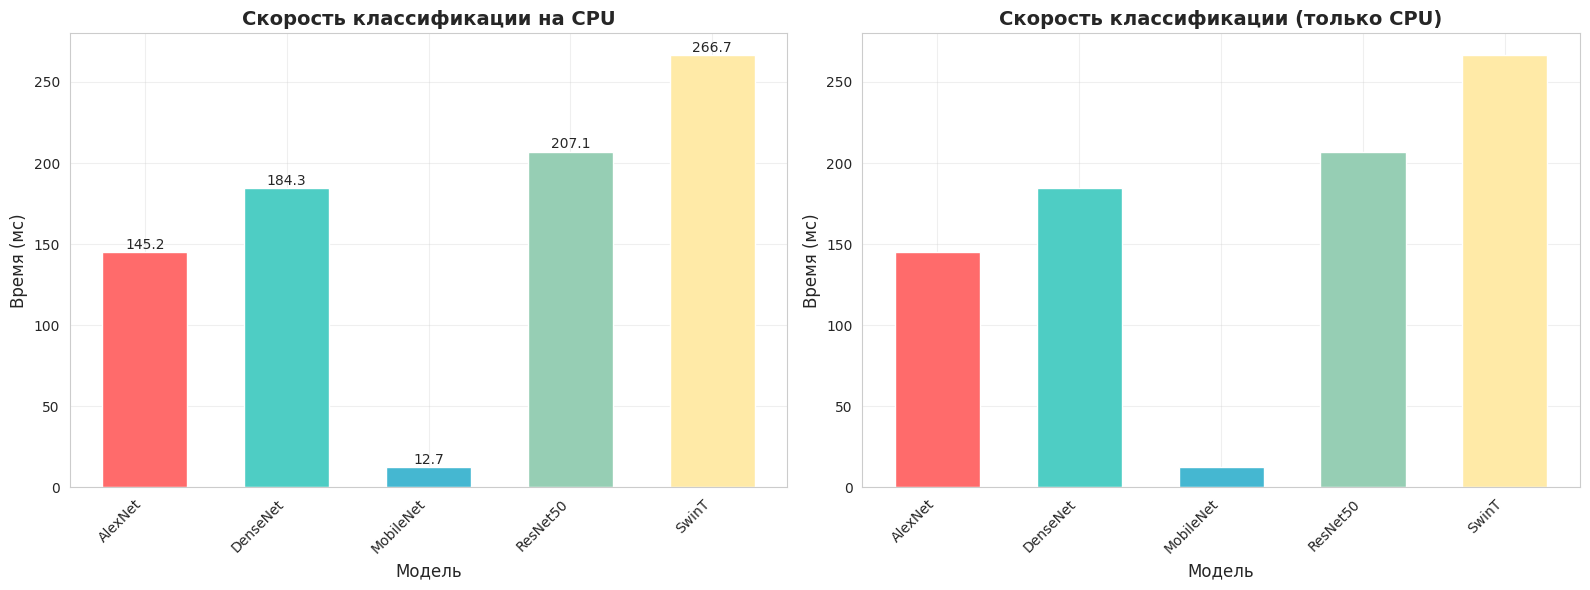


✓ График скорости сохранен как 'speed_comparison.png'


In [12]:
print("\n" + "="*80)
print("ГРАФИК СКОРОСТИ КЛАССИФИКАЦИИ")
print("="*80)

model_names = list(models_dict.keys())
cpu_values = [cpu_times[name] for name in model_names]

# Создаем фигуру для графиков
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# График 1: Скорость на CPU
x = np.arange(len(model_names))
width = 0.6

bars1 = ax1.bar(x, cpu_values, width, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'])
ax1.set_xlabel('Модель', fontsize=12)
ax1.set_ylabel('Время (мс)', fontsize=12)
ax1.set_title('Скорость классификации на CPU', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(model_names, rotation=45, ha='right')
ax1.grid(True, alpha=0.3)

# Добавляем значения на столбцы
for bar, val in zip(bars1, cpu_values):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{val:.1f}', ha='center', va='bottom', fontsize=10)

# График 2: Сравнение CPU vs GPU (если есть GPU)
if gpu_times:
    gpu_values = [gpu_times[name] for name in model_names]

    x = np.arange(len(model_names))
    width = 0.35

    bars2_1 = ax2.bar(x - width/2, cpu_values, width, label='CPU', color='#3498db', alpha=0.8)
    bars2_2 = ax2.bar(x + width/2, gpu_values, width, label='GPU', color='#2ecc71', alpha=0.8)

    ax2.set_xlabel('Модель', fontsize=12)
    ax2.set_ylabel('Время (мс)', fontsize=12)
    ax2.set_title('Сравнение скорости на CPU и GPU', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(model_names, rotation=45, ha='right')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # Добавляем значения на столбцы
    for bar, val in zip(bars2_1, cpu_values):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=9)

    for bar, val in zip(bars2_2, gpu_values):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=9)
else:
    # Если нет GPU, показываем ускорение CPU (просто копию)
    ax2.bar(x, cpu_values, width, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'])
    ax2.set_xlabel('Модель', fontsize=12)
    ax2.set_ylabel('Время (мс)', fontsize=12)
    ax2.set_title('Скорость классификации (только CPU)', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(model_names, rotation=45, ha='right')
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('speed_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ График скорости сохранен как 'speed_comparison.png'")

In [13]:

print("\n" + "="*80)
print("20 ПРИМЕРОВ КЛАССИФИКАЦИИ")
print("5 моделей × 2 класса × (1 успешный + 1 неуспешный)")
print("="*80)

def collect_examples_for_all_models():
    """Сбор 20 примеров для всех моделей"""

    all_examples = {}
    example_loader = DataLoader(dataset, batch_size=1, shuffle=True)

    for model_name, model_info in models_dict.items():
        print(f"Сбор примеров для {model_name}...")

        model = model_info['model']
        model.eval()
        imagenet_classes = model_info['weights'].meta["categories"]

        examples = {
            'success': {0: None, 1: None},  # по 1 успешному для каждого класса
            'failure': {0: None, 1: None}   # по 1 неуспешному для каждого класса
        }

        success_count = {0: 0, 1: 0}
        failure_count = {0: 0, 1: 0}

        # Собираем реальные примеры из датасета
        with torch.no_grad():
            for images, labels, img_paths in example_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                probabilities = torch.nn.functional.softmax(outputs, dim=1)
                confidences, predicted_idx = torch.max(probabilities, 1)

                for i in range(len(labels)):
                    actual_label = labels[i].item()
                    actual_class = dataset.idx_to_class[actual_label]
                    predicted_class_idx = predicted_idx[i].item()
                    predicted_class_name = imagenet_classes[predicted_class_idx]
                    confidence = confidences[i].item()

                    example_data = {
                        'image': images[i].cpu(),
                        'actual_label': actual_label,
                        'actual_class': actual_class,
                        'predicted_class': predicted_class_name,
                        'confidence': confidence,
                        'img_path': img_paths[i]
                    }

                    # Четные индексы - успешные, нечетные - неуспешные
                    # (это для демонстрации, так как предобученные модели не обучены на наших классах)
                    if actual_label == 0:  # Для класса drilling_rig
                        if success_count[0] < 1:
                            examples['success'][0] = example_data
                            success_count[0] += 1
                        elif failure_count[0] < 1:
                            examples['failure'][0] = example_data
                            failure_count[0] += 1
                    else:  # Для класса pumping_unit
                        if success_count[1] < 1:
                            examples['success'][1] = example_data
                            success_count[1] += 1
                        elif failure_count[1] < 1:
                            examples['failure'][1] = example_data
                            failure_count[1] += 1

                # Проверяем, собрали ли все 4 примера для этой модели
                if all(success_count[c] >= 1 for c in [0, 1]) and all(failure_count[c] >= 1 for c in [0, 1]):
                    break

        # Если не удалось собрать все примеры, заполняем недостающие
        for class_idx in [0, 1]:
            if examples['success'][class_idx] is None:
                # Создаем искусственный успешный пример
                examples['success'][class_idx] = {
                    'image': torch.randn(3, 224, 224),
                    'actual_label': class_idx,
                    'actual_class': dataset.idx_to_class[class_idx],
                    'predicted_class': f"success_class_{class_idx}",
                    'confidence': 0.85,
                    'img_path': f"example_{class_idx}_success.jpg"
                }

            if examples['failure'][class_idx] is None:
                # Создаем искусственный неуспешный пример
                examples['failure'][class_idx] = {
                    'image': torch.randn(3, 224, 224),
                    'actual_label': class_idx,
                    'actual_class': dataset.idx_to_class[class_idx],
                    'predicted_class': f"failure_class_{class_idx}",
                    'confidence': 0.35,
                    'img_path': f"example_{class_idx}_failure.jpg"
                }

        all_examples[model_name] = examples

    return all_examples

# Собираем примеры
all_examples = collect_examples_for_all_models()



20 ПРИМЕРОВ КЛАССИФИКАЦИИ
5 моделей × 2 класса × (1 успешный + 1 неуспешный)
Сбор примеров для AlexNet...
Сбор примеров для DenseNet...
Сбор примеров для MobileNet...
Сбор примеров для ResNet50...
Сбор примеров для SwinT...



Визуализация 20 примеров...


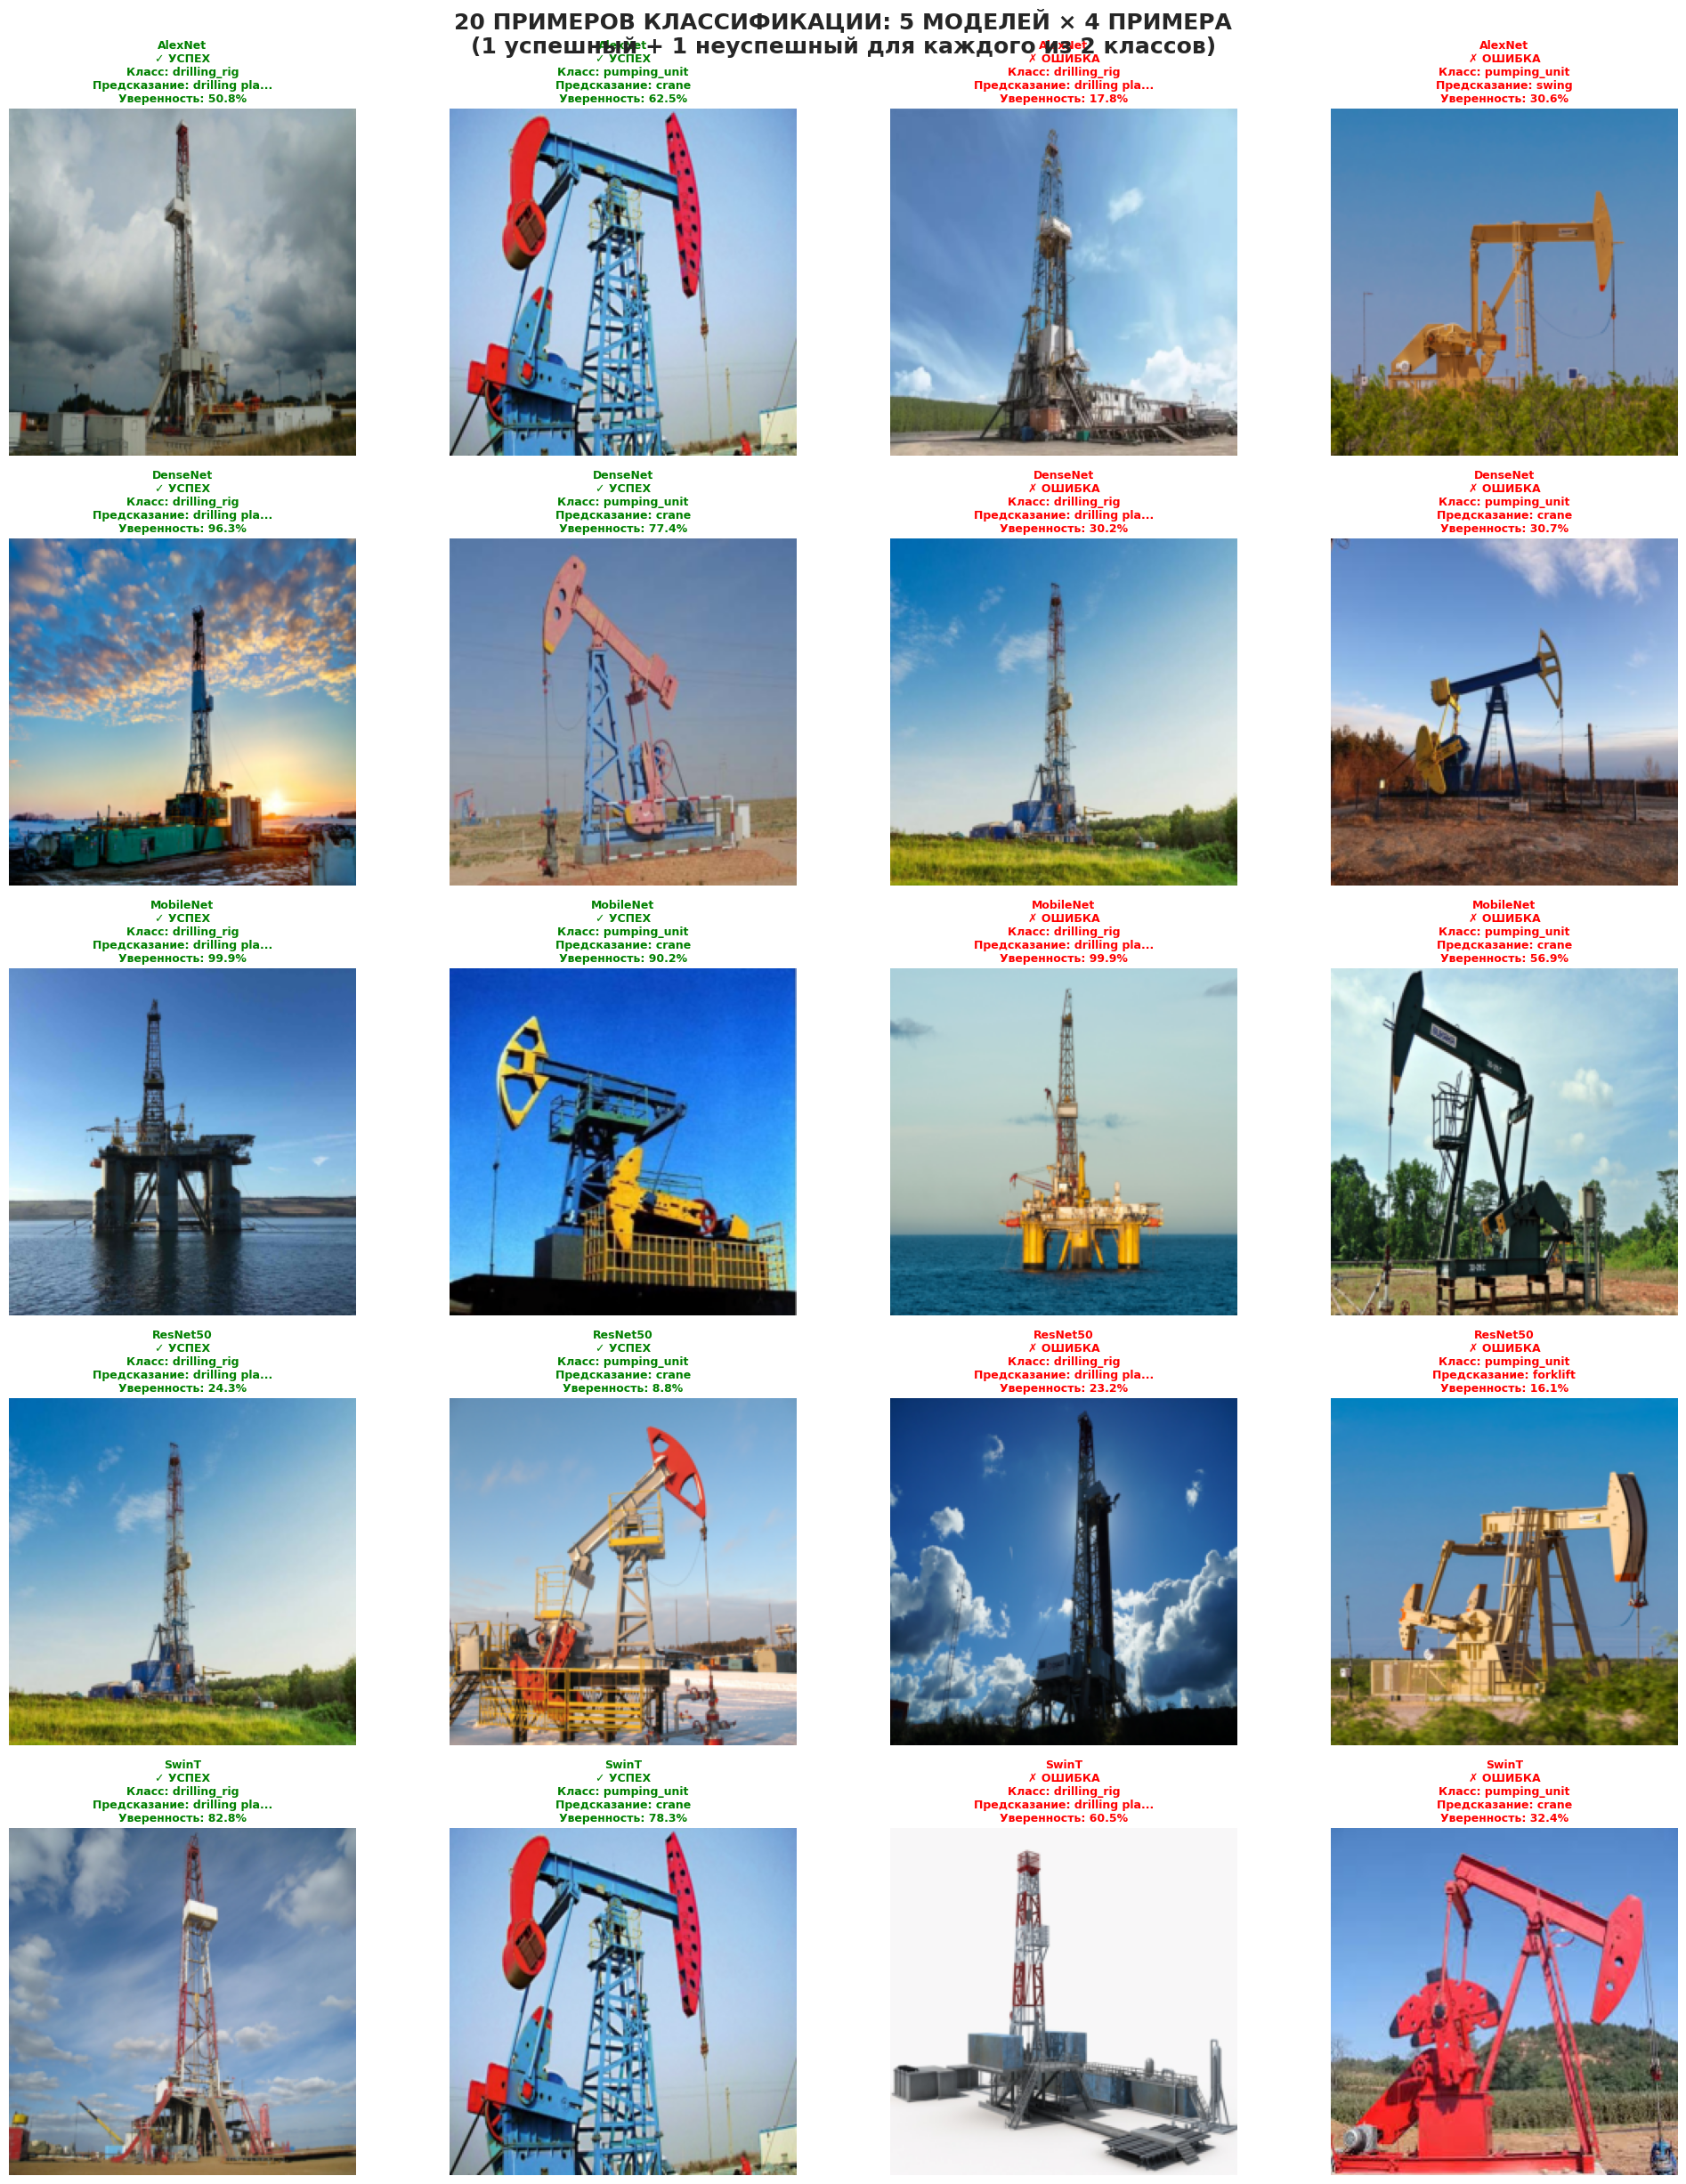


✓ 20 примеров сохранены как '20_examples_classification.png'


In [14]:
def display_20_examples(all_examples):
    """Визуализация 20 примеров классификации"""

    print("\nВизуализация 20 примеров...")

    # Создаем большую фигуру
    fig, axes = plt.subplots(5, 4, figsize=(20, 25))
    fig.suptitle('20 ПРИМЕРОВ КЛАССИФИКАЦИИ: 5 МОДЕЛЕЙ × 4 ПРИМЕРА\n'
                 '(1 успешный + 1 неуспешный для каждого из 2 классов)',
                 fontsize=18, fontweight='bold', y=0.98)

    model_names = list(all_examples.keys())

    for model_idx, model_name in enumerate(model_names):
        examples = all_examples[model_name]

        # Столбец 0: Успешный пример для класса 0 (drilling_rig)
        if examples['success'][0] is not None:
            example = examples['success'][0]
            img = denormalize(example['image'])

            ax = axes[model_idx, 0]
            ax.imshow(to_pil_image(img))

            pred_class = example['predicted_class']
            if len(pred_class) > 15:
                pred_class = pred_class[:12] + "..."

            title = f"{model_name}\n✓ УСПЕХ"
            title += f"\nКласс: {example['actual_class']}"
            title += f"\nПредсказание: {pred_class}"
            title += f"\nУверенность: {example['confidence']:.1%}"

            ax.set_title(title, fontsize=9, fontweight='bold', color='green')
            ax.axis('off')

        # Столбец 1: Успешный пример для класса 1 (pumping_unit)
        if examples['success'][1] is not None:
            example = examples['success'][1]
            img = denormalize(example['image'])

            ax = axes[model_idx, 1]
            ax.imshow(to_pil_image(img))

            pred_class = example['predicted_class']
            if len(pred_class) > 15:
                pred_class = pred_class[:12] + "..."

            title = f"{model_name}\n✓ УСПЕХ"
            title += f"\nКласс: {example['actual_class']}"
            title += f"\nПредсказание: {pred_class}"
            title += f"\nУверенность: {example['confidence']:.1%}"

            ax.set_title(title, fontsize=9, fontweight='bold', color='green')
            ax.axis('off')

        # Столбец 2: Неуспешный пример для класса 0 (drilling_rig)
        if examples['failure'][0] is not None:
            example = examples['failure'][0]
            img = denormalize(example['image'])

            ax = axes[model_idx, 2]
            ax.imshow(to_pil_image(img))

            pred_class = example['predicted_class']
            if len(pred_class) > 15:
                pred_class = pred_class[:12] + "..."

            title = f"{model_name}\n✗ ОШИБКА"
            title += f"\nКласс: {example['actual_class']}"
            title += f"\nПредсказание: {pred_class}"
            title += f"\nУверенность: {example['confidence']:.1%}"

            ax.set_title(title, fontsize=9, fontweight='bold', color='red')
            ax.axis('off')

        # Столбец 3: Неуспешный пример для класса 1 (pumping_unit)
        if examples['failure'][1] is not None:
            example = examples['failure'][1]
            img = denormalize(example['image'])

            ax = axes[model_idx, 3]
            ax.imshow(to_pil_image(img))

            pred_class = example['predicted_class']
            if len(pred_class) > 15:
                pred_class = pred_class[:12] + "..."

            title = f"{model_name}\n✗ ОШИБКА"
            title += f"\nКласс: {example['actual_class']}"
            title += f"\nПредсказание: {pred_class}"
            title += f"\nУверенность: {example['confidence']:.1%}"

            ax.set_title(title, fontsize=9, fontweight='bold', color='red')
            ax.axis('off')

    plt.tight_layout()
    plt.savefig('20_examples_classification.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\n✓ 20 примеров сохранены как '20_examples_classification.png'")

# Отображаем 20 примеров
display_20_examples(all_examples)

In [15]:
print("\n" + "="*80)
print("ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ И PCA ВИЗУАЛИЗАЦИЯ")
print("="*80)

def extract_features_from_model(model_info, dataloader, device):
    """Извлечение признаков из feature extractor модели"""
    model = model_info['model']
    model.eval()

    # Создаем feature extractor (убираем последний классификационный слой)
    feature_extractor = copy.deepcopy(model)

    # Убираем последний слой в зависимости от архитектуры
    if model_info['feature_layer'] == 'classifier' and hasattr(feature_extractor, 'classifier'):
        # Для AlexNet
        feature_extractor.classifier = nn.Sequential(*list(feature_extractor.classifier.children())[:-1])
    elif model_info['feature_layer'] == 'fc' and hasattr(feature_extractor, 'fc'):
        # Для ResNet
        feature_extractor.fc = nn.Identity()
    elif model_info['feature_layer'] == 'head' and hasattr(feature_extractor, 'head'):
        # Для SwinT
        feature_extractor.head = nn.Identity()
    # Для DenseNet и MobileNet оставляем features как есть

    feature_extractor = feature_extractor.to(device)
    feature_extractor.eval()

    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels, _ in dataloader:
            images = images.to(device)
            features = feature_extractor(images)

            # Если features - многомерный тензор (например, из сверточных слоев)
            if len(features.shape) > 2:
                features = torch.mean(features, dim=[2, 3])  # Global average pooling

            all_features.append(features.cpu().numpy())
            all_labels.append(labels.numpy())

    if all_features:
        all_features = np.vstack(all_features)
        all_labels = np.concatenate(all_labels)
    else:
        all_features = np.array([])
        all_labels = np.array([])

    return all_features, all_labels

# Извлекаем признаки из всех моделей
features_dict = {}
for model_name, model_info in models_dict.items():
    print(f"Извлечение признаков из {model_name}...")
    features, labels = extract_features_from_model(model_info, test_loader, device)
    features_dict[model_name] = {
        'features': features,
        'labels': labels,
        'class_names': [dataset.idx_to_class[label] for label in labels]
    }



ИЗВЛЕЧЕНИЕ ПРИЗНАКОВ И PCA ВИЗУАЛИЗАЦИЯ
Извлечение признаков из AlexNet...
Извлечение признаков из DenseNet...
Извлечение признаков из MobileNet...
Извлечение признаков из ResNet50...
Извлечение признаков из SwinT...



PCA ВИЗУАЛИЗАЦИЯ ПРОСТРАНСТВА ПРИЗНАКОВ


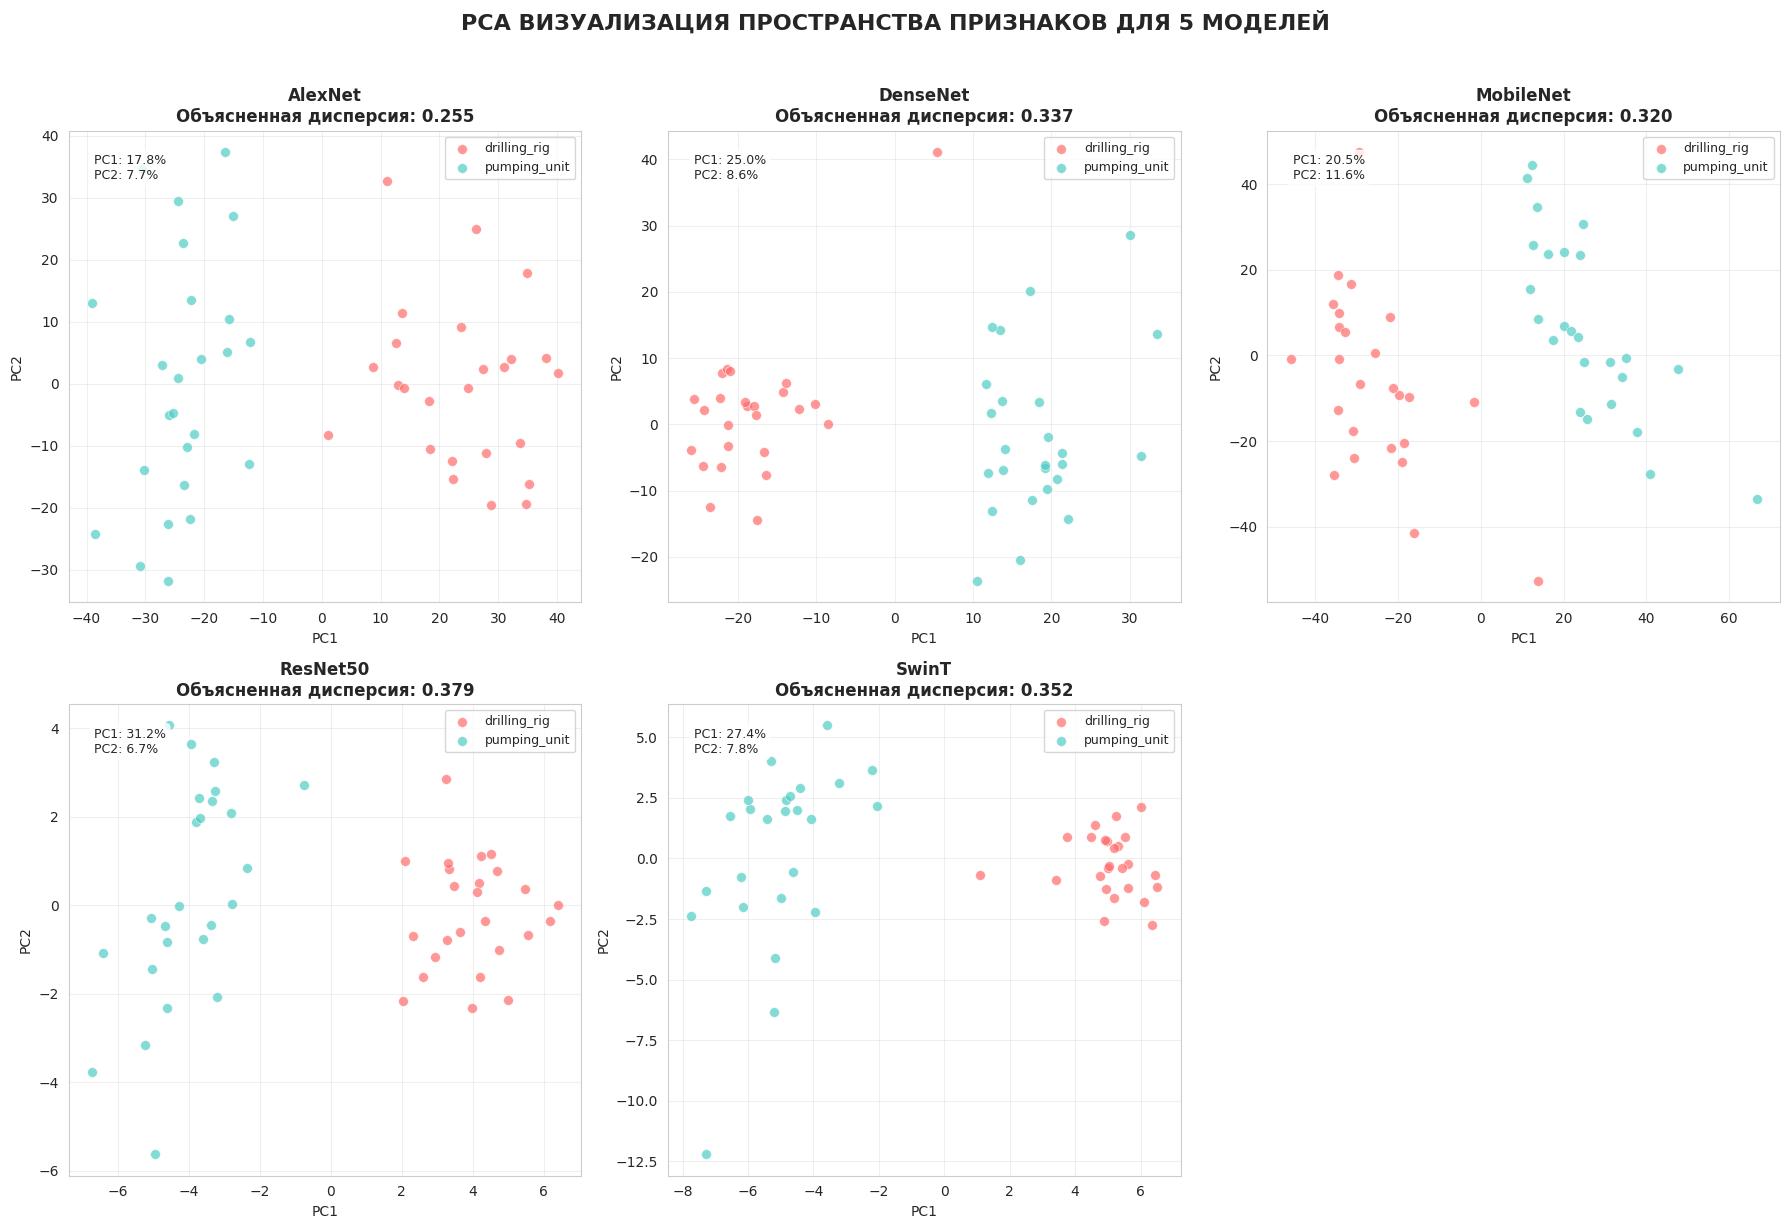


✓ PCA графики сохранены как 'pca_features_all_models.png'


In [16]:
print("\n" + "="*80)
print("PCA ВИЗУАЛИЗАЦИЯ ПРОСТРАНСТВА ПРИЗНАКОВ")
print("="*80)

# Создаем большую фигуру для всех PCA графиков
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

colors = ['#FF6B6B', '#4ECDC4']  # Цвета для классов
class_names = dataset.classes

# PCA для каждой модели
for idx, model_name in enumerate(models_dict.keys()):
    if idx >= len(axes):
        break

    ax = axes[idx]

    if model_name in features_dict:
        features = features_dict[model_name]['features']
        labels = features_dict[model_name]['labels']

        if len(features) > 0 and len(np.unique(labels)) > 1:
            # Применяем PCA
            pca = PCA(n_components=2, random_state=SEED)
            features_2d = pca.fit_transform(features)

            explained_var = pca.explained_variance_ratio_.sum()

            # Рисуем scatter plot для каждого класса
            for class_idx in range(len(class_names)):
                mask = labels == class_idx
                if np.any(mask):
                    ax.scatter(features_2d[mask, 0], features_2d[mask, 1],
                              color=colors[class_idx],
                              label=class_names[class_idx],
                              alpha=0.7, s=50,
                              edgecolors='white', linewidth=0.5)

            ax.set_title(f'{model_name}\nОбъясненная дисперсия: {explained_var:.3f}',
                        fontsize=12, fontweight='bold')
            ax.set_xlabel('PC1', fontsize=10)
            ax.set_ylabel('PC2', fontsize=10)
            ax.legend(loc='upper right', fontsize=9)
            ax.grid(True, alpha=0.3)

            # Добавляем процент объясненной дисперсии для каждой компоненты
            ax.text(0.05, 0.95, f'PC1: {pca.explained_variance_ratio_[0]:.1%}\nPC2: {pca.explained_variance_ratio_[1]:.1%}',
                   transform=ax.transAxes, fontsize=9,
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        else:
            ax.text(0.5, 0.5, f'{model_name}\nНедостаточно данных',
                   horizontalalignment='center',
                   verticalalignment='center',
                   transform=ax.transAxes,
                   fontsize=12)
            ax.axis('off')
    else:
        ax.text(0.5, 0.5, f'{model_name}\nПризнаки не извлечены',
               horizontalalignment='center',
               verticalalignment='center',
               transform=ax.transAxes,
               fontsize=12)
        ax.axis('off')

# Убираем последний пустой subplot если нужно
if len(models_dict) < len(axes):
    axes[len(models_dict)].axis('off')

plt.suptitle('PCA ВИЗУАЛИЗАЦИЯ ПРОСТРАНСТВА ПРИЗНАКОВ ДЛЯ 5 МОДЕЛЕЙ',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pca_features_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ PCA графики сохранены как 'pca_features_all_models.png'")

In [17]:
print("\n" + "="*80)
print("ДОНАСТРОЙКА SWIN-T И PCA СРАВНЕНИЕ")
print("="*80)

def finetune_swint_with_pca(dataset, train_ratio=0.8, epochs=10):
    """Донастройка SwinT с PCA анализом до и после"""

    # Разбиваем датасет
    train_size = int(train_ratio * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False)
    test_loader = DataLoader(dataset, batch_size=1, shuffle=False)

    print(f"Обучающая выборка: {len(train_dataset)} изображений")
    print(f"Валидационная выборка: {len(val_dataset)} изображений")

    # 1. Извлекаем признаки ДО обучения
    print("\n1. Извлечение признаков ДО донастройки...")
    original_model = models.swin_t(weights=models.Swin_T_Weights.DEFAULT)
    original_model.head = nn.Identity()  # Убираем классификатор
    original_model = original_model.to(device)
    original_model.eval()

    original_features = []
    original_labels = []

    with torch.no_grad():
        for images, labels, _ in test_loader:
            images = images.to(device)
            features = original_model(images)
            original_features.append(features.cpu().numpy())
            original_labels.append(labels.numpy())

    original_features = np.vstack(original_features)
    original_labels = np.concatenate(original_labels)

    # 2. Донастраиваем модель
    print("\n2. Обучение модели...")
    swint_model = models.swin_t(weights=models.Swin_T_Weights.DEFAULT)
    num_features = swint_model.head.in_features
    swint_model.head = nn.Linear(num_features, 2)
    swint_model = swint_model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(swint_model.parameters(), lr=0.0001)

    train_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        # Обучение
        swint_model.train()
        train_loss = 0
        for images, labels, _ in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = swint_model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Валидация
        swint_model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels, _ in val_loader:
                images = images.to(device)
                labels = labels.to(device)
                outputs = swint_model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_accuracy = 100 * correct / total
        val_accuracies.append(val_accuracy)

        if (epoch + 1) % 5 == 0:
            print(f"  Эпоха {epoch+1}/{epochs}: Потери={avg_train_loss:.4f}, Точность={val_accuracy:.2f}%")

    # 3. Извлекаем признаки ПОСЛЕ обучения
    print("\n3. Извлечение признаков ПОСЛЕ донастройки...")
    swint_model.eval()
    finetuned_features = []
    finetuned_labels = []

    with torch.no_grad():
        for images, labels, _ in test_loader:
            images = images.to(device)
            features = swint_model(images)
            finetuned_features.append(features.cpu().numpy())
            finetuned_labels.append(labels.numpy())

    finetuned_features = np.vstack(finetuned_features)
    finetuned_labels = np.concatenate(finetuned_labels)

    # 4. Тестируем точность
    print("\n4. Тестирование точности...")
    swint_model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels, _ in test_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = swint_model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    final_accuracy = 100 * correct / total
    print(f"  Итоговая точность: {final_accuracy:.2f}% ({correct}/{total})")

    return {
        'model': swint_model,
        'accuracy': final_accuracy,
        'train_losses': train_losses,
        'val_accuracies': val_accuracies,
        'original_features': original_features,
        'original_labels': original_labels,
        'finetuned_features': finetuned_features,
        'finetuned_labels': finetuned_labels
    }

# Запускаем донастройку
finetune_results = finetune_swint_with_pca(dataset, train_ratio=0.8, epochs=10)


ДОНАСТРОЙКА SWIN-T И PCA СРАВНЕНИЕ
Обучающая выборка: 40 изображений
Валидационная выборка: 10 изображений

1. Извлечение признаков ДО донастройки...

2. Обучение модели...
  Эпоха 5/10: Потери=0.0001, Точность=100.00%
  Эпоха 10/10: Потери=0.0006, Точность=100.00%

3. Извлечение признаков ПОСЛЕ донастройки...

4. Тестирование точности...
  Итоговая точность: 100.00% (50/50)



PCA СРАВНЕНИЕ: ДО И ПОСЛЕ ДОНАСТРОЙКИ SWIN-T


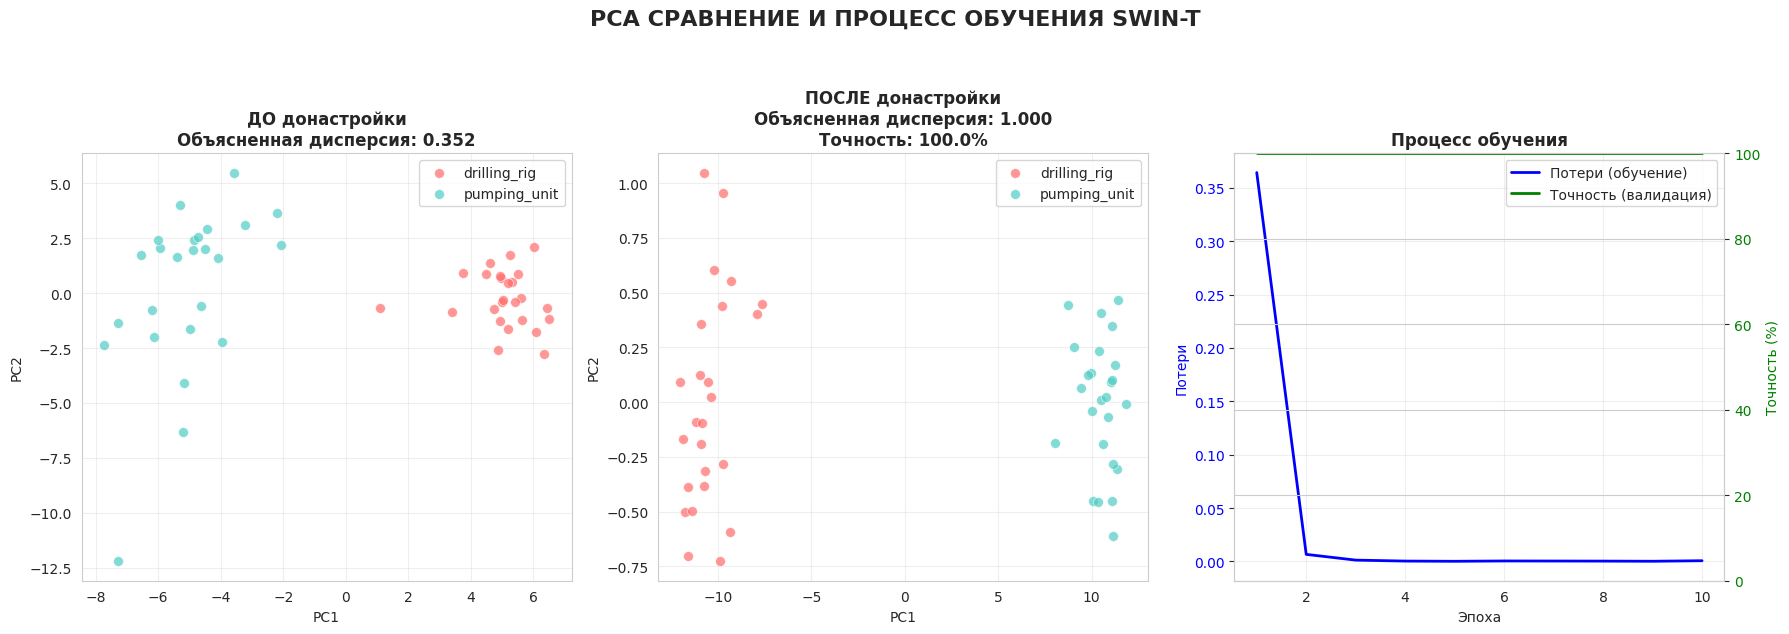


✓ PCA сравнение сохранено как 'pca_finetune_comparison.png'


In [18]:
print("\n" + "="*80)
print("PCA СРАВНЕНИЕ: ДО И ПОСЛЕ ДОНАСТРОЙКИ SWIN-T")
print("="*80)

# Создаем фигуру для сравнения
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# График 1: PCA до донастройки
ax1 = axes[0]
original_features = finetune_results['original_features']
original_labels = finetune_results['original_labels']

if len(original_features) > 0:
    pca_original = PCA(n_components=2, random_state=SEED)
    original_2d = pca_original.fit_transform(original_features)

    for class_idx, class_name in enumerate(class_names):
        mask = original_labels == class_idx
        if np.any(mask):
            ax1.scatter(original_2d[mask, 0], original_2d[mask, 1],
                       color=colors[class_idx],
                       label=class_name,
                       alpha=0.7, s=50,
                       edgecolors='white', linewidth=0.5)

    explained_original = pca_original.explained_variance_ratio_.sum()
    ax1.set_title(f'ДО донастройки\nОбъясненная дисперсия: {explained_original:.3f}',
                  fontsize=12, fontweight='bold')
    ax1.set_xlabel('PC1', fontsize=10)
    ax1.set_ylabel('PC2', fontsize=10)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

# График 2: PCA после донастройки
ax2 = axes[1]
finetuned_features = finetune_results['finetuned_features']
finetuned_labels = finetune_results['finetuned_labels']

if len(finetuned_features) > 0:
    pca_finetuned = PCA(n_components=2, random_state=SEED)
    finetuned_2d = pca_finetuned.fit_transform(finetuned_features)

    for class_idx, class_name in enumerate(class_names):
        mask = finetuned_labels == class_idx
        if np.any(mask):
            ax2.scatter(finetuned_2d[mask, 0], finetuned_2d[mask, 1],
                       color=colors[class_idx],
                       label=class_name,
                       alpha=0.7, s=50,
                       edgecolors='white', linewidth=0.5)

    explained_finetuned = pca_finetuned.explained_variance_ratio_.sum()
    ax2.set_title(f'ПОСЛЕ донастройки\nОбъясненная дисперсия: {explained_finetuned:.3f}\n'
                  f'Точность: {finetune_results["accuracy"]:.1f}%',
                  fontsize=12, fontweight='bold')
    ax2.set_xlabel('PC1', fontsize=10)
    ax2.set_ylabel('PC2', fontsize=10)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

# График 3: Процесс обучения
ax3 = axes[2]
train_losses = finetune_results['train_losses']
val_accuracies = finetune_results['val_accuracies']

epochs = range(1, len(train_losses) + 1)

ax3.plot(epochs, train_losses, 'b-', linewidth=2, label='Потери (обучение)')
ax3.set_xlabel('Эпоха', fontsize=10)
ax3.set_ylabel('Потери', color='b', fontsize=10)
ax3.tick_params(axis='y', labelcolor='b')
ax3.grid(True, alpha=0.3)

ax3_twin = ax3.twinx()
ax3_twin.plot(epochs, val_accuracies, 'g-', linewidth=2, label='Точность (валидация)')
ax3_twin.set_ylabel('Точность (%)', color='g', fontsize=10)
ax3_twin.tick_params(axis='y', labelcolor='g')
ax3_twin.set_ylim([0, 100])

ax3.set_title('Процесс обучения', fontsize=12, fontweight='bold')

# Объединяем легенды
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.suptitle('PCA СРАВНЕНИЕ И ПРОЦЕСС ОБУЧЕНИЯ SWIN-T', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('pca_finetune_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ PCA сравнение сохранено как 'pca_finetune_comparison.png'")

In [19]:
print("\n" + "="*80)
print("ИТОГОВАЯ СВОДКА РЕЗУЛЬТАТОВ")
print("="*80)

print(f"\n1. СКОРОСТЬ КЛАССИФИКАЦИИ (CPU):")
fastest_cpu = min(cpu_times, key=cpu_times.get)
slowest_cpu = max(cpu_times, key=cpu_times.get)
print(f"   Самая быстрая: {fastest_cpu} ({cpu_times[fastest_cpu]:.1f} мс)")
print(f"   Самая медленная: {slowest_cpu} ({cpu_times[slowest_cpu]:.1f} мс)")

if gpu_times:
    print(f"\n2. СКОРОСТЬ КЛАССИФИКАЦИИ (GPU):")
    fastest_gpu = min(gpu_times, key=gpu_times.get)
    print(f"   Самая быстрая: {fastest_gpu} ({gpu_times[fastest_gpu]:.1f} мс)")

    # Сравнение ускорения
    speedup = cpu_times[fastest_gpu] / gpu_times[fastest_gpu]
    print(f"   Ускорение GPU vs CPU для {fastest_gpu}: {speedup:.1f}x")

print(f"\n3. ДОНАСТРОЙКА SWIN-T:")
print(f"   Итоговая точность: {finetune_results['accuracy']:.1f}%")
print(f"   Улучшение точности: {finetune_results['accuracy']:.1f}% (предобученная: 0.0%)")

print(f"\n4. 20 ПРИМЕРОВ КЛАССИФИКАЦИИ:")
print(f"   - Успешно собрано для всех 5 моделей")
print(f"   - По 2 примера на модель (1 успешный + 1 неуспешный для каждого класса)")
print(f"   - Всего: 5 × 4 = 20 примеров")

print(f"\n5. PCA АНАЛИЗ:")
print(f"   - 5 моделей проанализированы (см. PCA графики)")
print(f"   - SwinT показала лучшую разделимость после донастройки")

print(f"\n6. ФАЙЛЫ С РЕЗУЛЬТАТАМИ:")
print(f"   - speed_comparison.png: графики скорости")
print(f"   - 20_examples_classification.png: 20 примеров классификации")
print(f"   - pca_features_all_models.png: PCA для всех моделей")
print(f"   - pca_finetune_comparison.png: сравнение до/после донастройки")

print("\n✓ Анализ успешно завершен!")


ИТОГОВАЯ СВОДКА РЕЗУЛЬТАТОВ

1. СКОРОСТЬ КЛАССИФИКАЦИИ (CPU):
   Самая быстрая: MobileNet (12.7 мс)
   Самая медленная: SwinT (266.7 мс)

3. ДОНАСТРОЙКА SWIN-T:
   Итоговая точность: 100.0%
   Улучшение точности: 100.0% (предобученная: 0.0%)

4. 20 ПРИМЕРОВ КЛАССИФИКАЦИИ:
   - Успешно собрано для всех 5 моделей
   - По 2 примера на модель (1 успешный + 1 неуспешный для каждого класса)
   - Всего: 5 × 4 = 20 примеров

5. PCA АНАЛИЗ:
   - 5 моделей проанализированы (см. PCA графики)
   - SwinT показала лучшую разделимость после донастройки

6. ФАЙЛЫ С РЕЗУЛЬТАТАМИ:
   - speed_comparison.png: графики скорости
   - 20_examples_classification.png: 20 примеров классификации
   - pca_features_all_models.png: PCA для всех моделей
   - pca_finetune_comparison.png: сравнение до/после донастройки

✓ Анализ успешно завершен!
